<a href="https://colab.research.google.com/github/Shubh3155/deep-learning/blob/main/CatsVsDogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
import tensorflow_datasets as tfds

In [2]:
(train_ds, val_ds), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,   # returns (image, label) pairs
    with_info=True
)

print("Dataset loaded ✅")
print(f"Total training samples : {info.splits['train'].num_examples}")
print(f"Classes                : 0 = Cat, 1 = Dog")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.UBORK7_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset loaded ✅
Total training samples : 23262
Classes                : 0 = Cat, 1 = Dog


In [3]:
def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))  # resize to 224×224
    image = image / 255.0                        # normalize 0-1
    return image, label

train_ds = train_ds.map(preprocess).batch(32)
val_ds   = val_ds.map(preprocess).batch(32)

print("Data prepared:")
print(f"  Image size : 224×224 pixels (VGG16 requirement)")
print(f"  Channels   : 3 (RGB color — unlike MNIST's 1 grayscale channel)")
print(f"  Batch size : 32")

Data prepared:
  Image size : 224×224 pixels (VGG16 requirement)
  Channels   : 3 (RGB color — unlike MNIST's 1 grayscale channel)
  Batch size : 32


In [4]:
base_model = VGG16(
    weights='imagenet',      # use weights trained on 1.2M ImageNet images
    include_top=False,       # remove the final 1000-class layer
    input_shape=(224, 224, 3)
)

# FREEZE all pretrained layers
# We don't want to change what VGG16 already learned
base_model.trainable = False

print("VGG16 loaded and frozen ✅")
print(f"VGG16 layers frozen  : {len(base_model.layers)}")
print("These layers already know: edges, curves, textures, shapes")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded and frozen ✅
VGG16 layers frozen  : 19
These layers already know: edges, curves, textures, shapes


In [5]:
model = keras.Sequential([
    base_model,                           # frozen VGG16 — feature extractor
    layers.Flatten(),                     # flatten feature maps to 1D
    layers.Dense(128, activation='relu'), # our new layer — learns Cat vs Dog patterns
    layers.Dense(1, activation='sigmoid') # 1 neuron output
    # sigmoid: value > 0.5 = Dog, value < 0.5 = Cat
    # (Binary classification uses 1 neuron, not 2)
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # 2 classes → binary crossentropy (not sparse categorical)
    metrics=['accuracy']
)

model.summary()
print("\nNote: Most parameters are NON-TRAINABLE (frozen VGG16)")
print("Only our new Dense layers are trainable ✅")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Note: Most parameters are NON-TRAINABLE (frozen VGG16)
Only our new Dense layers are trainable ✅


In [6]:
# ── PHASE 2: TRAIN (only our new layers train) ───────────────────
# Much faster than training everything
# Colab GPU recommended: ~3-5 mins | CPU: ~30-40 mins

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 167s 261ms/step - accuracy: 0.9009 - loss: 0.2511 - val_accuracy: 0.9196 - val_loss: 0.1855
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 135s 232ms/step - accuracy: 0.9442 - loss: 0.1387 - val_accuracy: 0.9035 - val_loss: 0.2431
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 136s 234ms/step - accuracy: 0.9586 - loss: 0.1076 - val_accuracy: 0.9198 - val_loss: 0.2270
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 136s 233ms/step - accuracy: 0.9508 - loss: 0.1214 - val_accuracy: 0.9194 - val_loss: 0.2230
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 136s 233ms/step - accuracy: 0.9608 - loss: 0.0939 - val_accuracy: 0.9230 - val_loss: 0.2327


In [7]:

# ── PHASE 3: EVALUATE ─────────────────────────────────────────────
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"Validation Accuracy : {round(val_acc * 100, 2)}%")

Validation Accuracy : 92.3%


/tmp/ipykernel_1184/2969366551.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1184/2969366551.py:23: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


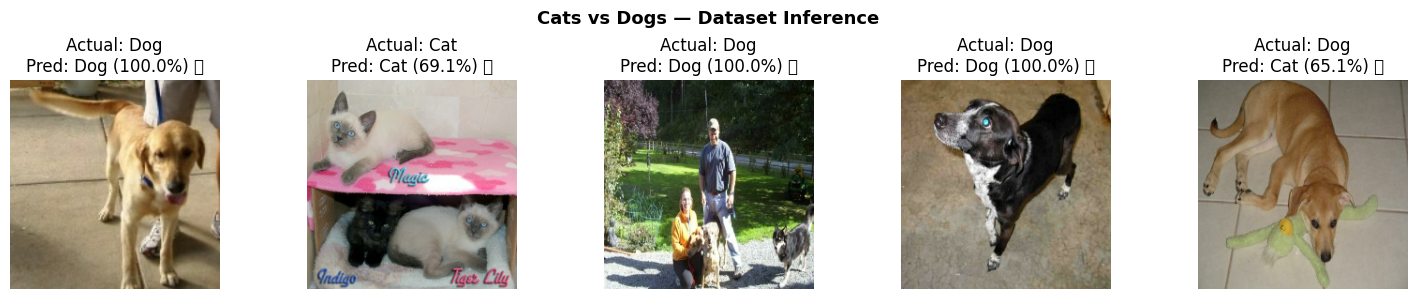

In [8]:
# ── PHASE 4: INFERENCE on dataset images ──────────────────────────
class_names = ['Cat', 'Dog']

sample_images, sample_labels = [], []
for img, lbl in val_ds.unbatch().take(5):
    sample_images.append(img.numpy())
    sample_labels.append(lbl.numpy())

predictions = model.predict(np.array(sample_images), verbose=0)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    ax = axes[i]
    ax.imshow(sample_images[i])
    pred_value    = float(predictions[i][0])
    pred_label    = 'Dog' if pred_value > 0.5 else 'Cat'
    confidence    = round(pred_value * 100, 1) if pred_value > 0.5 else round((1 - pred_value) * 100, 1)
    actual        = class_names[sample_labels[i]]
    status        = "✅" if pred_label == actual else "❌"
    ax.set_title(f"Actual: {actual}\nPred: {pred_label} ({confidence}%) {status}")
    ax.axis('off')
plt.suptitle("Cats vs Dogs — Dataset Inference", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Saving dog-portrait.webp to dog-portrait.webp


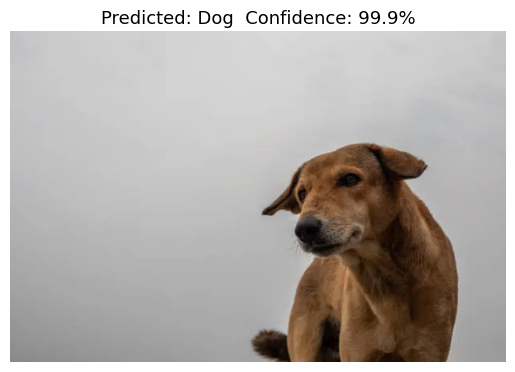

Predicted  → Dog
Confidence → 99.9%


In [9]:

# ── PHASE 4: INFERENCE on YOUR OWN image ─────────────────────────
# Upload any cat or dog photo

# ---- On Google Colab ----
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ---- On Local / VSCode ----
# filename = input("Enter full path to your cat or dog image: ")
# Example: C:/Users/YourName/Downloads/cat.jpg

from PIL import Image

img = Image.open(filename).convert('RGB')
img_resized = img.resize((224, 224))           # VGG16 needs 224×224
img_array   = np.array(img_resized) / 255.0
img_array   = img_array.reshape(1, 224, 224, 3)

prediction    = model.predict(img_array, verbose=0)
pred_value    = float(prediction[0][0])
pred_label    = 'Dog' if pred_value > 0.5 else 'Cat'
confidence    = round(pred_value * 100, 1) if pred_value > 0.5 else round((1 - pred_value) * 100, 1)

plt.imshow(img)
plt.title(f"Predicted: {pred_label}  Confidence: {confidence}%", fontsize=13)
plt.axis('off')
plt.show()

print(f"Predicted  → {pred_label}")
print(f"Confidence → {confidence}%")